In [2]:
import pickle
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [3]:
POSTERIOR_DIRECTORY = '../data/posteriors/custom_forecast_w0waCDM_fixed_scatter'

## Prepare Datasets for the Forecast

In [3]:
# Load the pdspl_samples object
with open('../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

In [4]:
# --- 1. CONFIGURATION & TRUTH ---
truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
fixed_params = {'h0': 70.0, 'gamma_sigma': 0.16, 'lambda_sigma': 0.05,}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

# --- 2. INITIALIZE SCENARIOS ---
scenarios = {}

redshift_errors_rel = {
    'DSPL': 0.0001, # spec-z
    'lsst_y1': 0.03, # photo-z
    'lsst_y10': 0.03, # photo-z
    'lsst_4most_spec-z': 0.0001, # spec-z
    'lsst_4most_spec-z_sigma_v': 0.0001, # spec-z
}

# Populate PDSPL scenarios from pickle
for key in pdspl_samples.keys():
    scenarios[key] = {
        'name': f"PDSPL ({pdspl_samples[key]['name']})",
        'down_sampling': len(pdspl_samples[key]['pairs_analysis']['pairs_table']) / 2000, # downsample to at most 2000 lenses for computational feasibility
        'num_lenses': len(pdspl_samples[key]['pairs_analysis']['pairs_table']),
        'color': pdspl_samples[key]['color'],
        'coeffs': pdspl_samples[key]['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
        'pairs_table': pdspl_samples[key]['pairs_analysis']['pairs_table'],
        'pairs_table_with_errors': pdspl_samples[key]['pairs_analysis']['pairs_table_with_errors'],
        'sigma_beta': pdspl_samples[key]['pairs_analysis']['scatter_in_beta_E'],
        'redshift_error_rel': redshift_errors_rel[key],
        'backend_path': POSTERIOR_DIRECTORY + f"/{key}.h5"
    }

# Append the custom synthetic DSPL scenario
scenarios['DSPL'] = {
    'name': 'DSPL (500 lenses)',
    'down_sampling': 1, # No downsampling for synthetic DSPL scenario
    'num_lenses': 500,
    'color': '#1f77b4',
    'sigma_beta': 0.00, # this is the intrinsic scatter in beta_E for the synthetic DSPL scenario, which we can set to zero since we are generating the data ourselves. The total scatter will be determined by the measurement and LOS contributions that we add in quadrature during data generation.
    'redshift_error_rel': redshift_errors_rel['DSPL'],
    'backend_path': POSTERIOR_DIRECTORY + f"/DSPL.h5"
}

# --- 3. GENERATE MOCK DATASETS ---
print(f"{'SCENARIO':<60} | {'N_LENS':<10} | {'STATUS'}")
print("-" * 85)

for key in scenarios.keys():
    sc = scenarios[key]
    num_samples = int(sc['num_lenses'] / sc['down_sampling'])
    kwargs_list = []
    
    if key == 'DSPL':
        # Synthetic generation for pure DSPL
        for _ in range(num_samples):
            z_lens = np.random.normal(loc=0.5, scale=0.1)
            z1 = np.random.uniform(low=z_lens + 0.1, high=3.0)
            z2 = np.random.uniform(low=z1 + 0.1, high=3.0)
            
            sigma_beta_meas, sigma_beta_los = 0.01, 0.01
            rel_scatter_in_beta_E = np.sqrt(sc['sigma_beta']**2 + sigma_beta_meas**2 + sigma_beta_los**2)
            
            kwargs_list.append(draw_lens_from_given_zs(
                z_lens=z_lens, z1=z1, z2=z2,
                lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
                gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
                sigma_beta_rel=rel_scatter_in_beta_E, 
                down_sampling=sc['down_sampling'], 
                with_noise=False, # For ASIMOV inference
                cosmo=cosmo_true,
                redshift_error_rel=sc['redshift_error_rel']
            ))
    else:
        # Generation from PDSPL tables
        pairs_table = sc['pairs_table']
        pairs_table_with_errors = sc['pairs_table_with_errors']
        coeffs = sc['coeffs']
        random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)
        
        for i in random_indices:
            z_lens = pairs_table["z_D"][i]
            z1 = pairs_table["z_S1"][i]
            z2 = pairs_table["z_S2"][i]
            
            dissimilarity = pairs_table_with_errors['dissimilarity'][i]
            rel_scatter_in_beta_E = np.polyval(coeffs, dissimilarity)
            
            sigma_beta_meas, sigma_beta_los = 0.01, 0.01
            rel_scatter_in_beta_E = np.sqrt(rel_scatter_in_beta_E**2 + sigma_beta_meas**2 + sigma_beta_los**2)
            
            kwargs_list.append(draw_lens_from_given_zs(
                z_lens=z_lens, z1=z1, z2=z2,
                lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
                gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
                sigma_beta_rel=rel_scatter_in_beta_E, 
                down_sampling=sc['down_sampling'], 
                with_noise=False, # For ASIMOV inference
                cosmo=cosmo_true, 
                redshift_error_rel=sc['redshift_error_rel']
            ))
            
    # Save the generated dataset into the scenario dictionary
    sc['kwargs_list'] = kwargs_list
    print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y1)                                              | 2000       | GENERATED
PDSPL (LSST Y10)                                             | 1999       | GENERATED
PDSPL (4MOST ($z^{\rm spec}$))                               | 2000       | GENERATED
PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$))             | 2000       | GENERATED
DSPL (500 lenses)                                            | 500        | GENERATED


In [5]:
original_keys = list(scenarios.keys())
print("original_keys:", original_keys)

original_keys: ['lsst_y1', 'lsst_y10', 'lsst_4most_spec-z', 'lsst_4most_spec-z_sigma_v', 'DSPL']


## Run the Forecast Inference

### a. Uniform Prior Forecasts

In [ ]:
# --- 1. INFERENCE SETTINGS ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0,
    'gamma_pl': 2.0,
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1,
    'gamma_pl': 0.1,
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
}

# --- 2. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers ---")

param_labels = None 

for key in scenarios.keys():
    sc = scenarios[key]
    
    if 'kwargs_list' not in sc:
        continue # Skip if data wasn't generated
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=2000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params,
        initial_scatter=my_spreads,
        priors=my_priors,
        down_sampling=sc['down_sampling'],
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    param_labels = labels # Saves labels for plotting step
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers ---

Running Inference for: PDSPL (LSST Y1)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'gamma_sigma', 'lambda_sigma']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'gamma_pl']
Down Sampling : 14.3795
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_fixed_scatter/lsst_y1.h5


100%|██████████| 2000/2000 [21:40<00:00,  1.54it/s]


PDSPL (LSST Y1) | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10)
--- Starting DSPL Inference ---
Fixed Params  : ['h0', 'gamma_sigma', 'lambda_sigma']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'gamma_pl']
Down Sampling : 42.968
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_fixed_scatter/lsst_y10.h5


  1%|▏         | 25/2000 [00:16<22:04,  1.49it/s]Process ForkPoolWorker-36:
Process ForkPoolWorker-26:
Process ForkPoolWorker-30:
Process ForkPoolWorker-27:
Process ForkPoolWorker-22:
Process ForkPoolWorker-24:
Process ForkPoolWorker-34:
Process ForkPoolWorker-33:
Process ForkPoolWorker-31:
Process ForkPoolWorker-38:
Process ForkPoolWorker-23:


emcee: Exception while calling your likelihood function:

...

  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py", line 1125, in _comoving_distance_z1z2
    return self._integral_comoving_distance_z1z2(z1, z2)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py", line 2537, in _call_as_normal
    return self._vectorize_call(func=func, args=vargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py", line 2625, in _vectorize_call
    outputs = ufunc(*args, out=...)
              ^^^^^^^^^^^^^^^^^^^^^


  exception:

  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py", line 1169, in _integral_comoving_distance_z1z2_scalar
    return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py", line 1146, in _integral_comoving_distance_z1z2
    return self.hubble_distance * self._integral_comoving_distance_z1z2_scalar(z1, z2)  # fmt: skip
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/astropy/cosmology/_src/flrw/base.py", line 1146, in _integral_comoving_distance_z1z2
    return self.hubble_distance * self._integral_comoving_distance_z1z2_scalar(z1, z2)  # fmt: skip
                                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/scipy/integrate/_quadpack_py.py", line 460, in quad
    retval = _quad(func, a, b, args, full_output, epsabs, epsrel, limit,
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Traceback (most recent call last):
  File "/home/paras/sharmapyenv/li

  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/scipy/integrate/_quadpack_py.py", line 607, in _quad
    return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paras/repos/self/pdspl-analysis/pdspl_utils/inference.py", line 258, in log_probability
    ll = self.log_likelihood(theta)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py", line 2537, in _call_as_normal
    return self._vectorize_call(func=func, args=vargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py", line 2625, in _vectorize_call
    outputs = ufunc(*args, out=...)
              ^^^^^^^^^^^^^^^^^^^^^
  File "/home/paras/sharmapyenv/lib64/python3.12/site-packages/numpy/lib/_function_base_impl.py", line 2544, in __call__
 

### b. Gaussian Omega_m Prior Forecasts

In [ ]:
# --- 1. INFERENCE SETTINGS ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 
    'gamma_pl': 2.0, 
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 
    'gamma_pl': 0.1, 
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('gaussian', 0.3, 0.05),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
}

# --- 2. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers for Forecast with Prior on Omega_m ---")

param_labels = None 

for key in original_keys:
    key_with_prior = key + '_om_prior'
    scenarios[key_with_prior] = scenarios[key].copy()
    scenarios[key_with_prior]['name'] += ' + $\\Omega_m$ Prior'
    scenarios[key_with_prior]['backend_path'] = POSTERIOR_DIRECTORY + f"/{key_with_prior}.h5"

for key in original_keys:
    key_with_prior = key + '_om_prior'
    sc = scenarios[key_with_prior]
    
    if 'kwargs_list' not in sc:
        continue # Skip if data wasn't generated
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=1000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params,
        initial_scatter=my_spreads,
        priors=my_priors,
        down_sampling=sc['down_sampling'],
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    param_labels = labels # Saves labels for plotting step
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers for Forecast with Prior on Omega_m ---

Running Inference for: PDSPL (LSST Y1) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 14.3795
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_y1_om_prior.h5


  1%|          | 9/1000 [00:06<13:22,  1.24it/s]

100%|██████████| 1000/1000 [10:41<00:00,  1.56it/s]


PDSPL (LSST Y1) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 42.968
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_y10_om_prior.h5


100%|██████████| 1000/1000 [10:50<00:00,  1.54it/s]


...

PDSPL (4MOST ($z^{\rm spec}$)) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 1.7805
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/lsst_4most_spec-z_sigma_v_om_prior.h5


100%|██████████| 1000/1000 [08:35<00:00,  1.94it/s]


PDSPL (4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)) + $\Omega_m$ Prior | INFERENCE COMPLETE

Running Inference for: DSPL (500 lenses) + $\Omega_m$ Prior
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 1
Saving to     : ../data/posteriors/custom_forecast_w0waCDM_scatter/DSPL_om_prior.h5


100%|██████████| 1000/1000 [04:16<00:00,  3.89it/s]

DSPL (500 lenses) + $\Omega_m$ Prior | INFERENCE COMPLETE


## Plotting the Forecast Results

In [ ]:
def plot_dspl_corner(scenarios, truth, fixed_params, scenarios_to_plot=None, 
                     custom_ranges=None, latex_labels=None, figsize=(12, 12),
                     show_multiple_titles=True, error_type='asymmetric',
                     title_y_spacing=0.15, samples_key='samples', 
                     custom_colors_dict=None):
    """
    Generates a combined corner plot for multiple MCMC scenarios with custom stacked titles.
    
    Parameters:
        scenarios (dict): Dictionary containing scenario data (samples, color, name, etc.).
        truth (dict): Dictionary of true parameter values.
        fixed_params (dict): Dictionary of fixed parameters to exclude from plotting.
        scenarios_to_plot (list): Keys of scenarios to plot. Defaults to all keys in scenarios.
        custom_ranges (list of tuples): Plot ranges for each parameter.
        latex_labels (dict): Mapping of parameter keys to LaTeX strings.
        figsize (tuple): Size of the resulting figure.
        show_multiple_titles (bool): If True, stacks colored titles on diagonal axes.
        error_type (str): 'asymmetric' (median +upper/-lower) or 'symmetric' (mean +/- std).
        title_y_spacing (float): Vertical spacing multiplier for stacking titles.
    
    Returns:
        fig: The generated matplotlib Figure object.
    """
    # 1. Setup Data and Labels
    if scenarios_to_plot is None:
        scenarios_to_plot = list(scenarios.keys())

    sampled_keys = [k for k in truth.keys() if k not in fixed_params]
    truth_values = [truth[k] for k in sampled_keys]
    
    if latex_labels is None:
        latex_labels = {k: k for k in sampled_keys}
    plot_labels = [latex_labels.get(k, k) for k in sampled_keys]

    fig = plt.figure(figsize=figsize)

    # Filter out scenarios that haven't been run yet
    valid_scenarios = [key for key in scenarios_to_plot if key in scenarios and 'samples' in scenarios[key]]

    colors_for_valid_scenarios = [scenarios[key]['color'] if custom_colors_dict is None else custom_colors_dict.get(key, scenarios[key]['color']) for key in valid_scenarios]

    # 2. Draw Contours
    for key in valid_scenarios:
        sc = scenarios[key]
        
        fig = corner.corner(
            sc[samples_key],
            fig=fig,
            labels=plot_labels,
            range=custom_ranges,
            color=colors_for_valid_scenarios[valid_scenarios.index(key)],
            weights=np.ones(len(sc[samples_key])) / len(sc[samples_key]),
            smooth=2,
            
            plot_datapoints=False,  
            plot_density=False,     
            fill_contours=True,    
            show_titles=False,      # Disabled so we can manually add multiple titles
            
            levels=[0.68, 0.95],    
            hist_kwargs={"density": True, "linewidth": 2, "histtype": "step"},
            contour_kwargs={"linewidths": 2},
            
            truths=truth_values, 
            truth_color="#444444",
            label_kwargs={"fontsize": 14}
        )

    # 3. Stacked Colored Titles
    if show_multiple_titles and valid_scenarios:
        ndim = len(sampled_keys)
        # Corner creates a flat list of axes; reshape to an N x N grid
        axes = np.array(fig.axes).reshape((ndim, ndim))
        
        for col_idx, param_key in enumerate(sampled_keys):
            # Extract the 1D histogram axis on the diagonal
            ax = axes[col_idx, col_idx] 
            
            # Get the latex label and strip existing $ signs for clean formatting
            param_label_raw = plot_labels[col_idx]
            param_math_text = param_label_raw.replace('$', '')
            
            for row_idx, sc_key in enumerate(valid_scenarios):
                sc = scenarios[sc_key]
                
                # Extract the 1D array of samples for this specific parameter
                samples_1d = sc['samples'][:, col_idx]
                
                if error_type == 'symmetric':
                    # Mean and Standard Deviation
                    mean_val = np.mean(samples_1d)
                    std_val = np.std(samples_1d)
                    title_str = fr"${param_math_text} = {mean_val:.2f} \pm {std_val:.2f}$"
                else:
                    # Asymmetric (Median and 16th/84th percentiles)
                    q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
                    lower_err = q50 - q16
                    upper_err = q84 - q50
                    title_str = fr"${param_math_text} = {q50:.2f}^{{+{upper_err:.2f}}}_{{-{lower_err:.2f}}}$"
                
                # Calculate vertical offset so text lines stack upward
                y_offset = 1.05 + (title_y_spacing * row_idx) 
                
                ax.text(0.5, y_offset, title_str, transform=ax.transAxes, 
                        ha='center', va='bottom', color=colors_for_valid_scenarios[valid_scenarios.index(sc_key)], fontsize=11)

    # 4. Custom Legend
    legend_handles = []
    for key in valid_scenarios:
        sc = scenarios[key]
        line = mlines.Line2D([], [], color=colors_for_valid_scenarios[valid_scenarios.index(key)], linewidth=3, 
                             label=f"{sc['name']}"# (N={sc['num_lenses']})"
                             )
        legend_handles.append(line)

    fig.legend(
        handles=legend_handles,
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98), 
        bbox_transform=fig.transFigure,
        fontsize=14,
        frameon=False
    )

    return fig

In [ ]:
latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
}

custom_ranges = [
    (0, 1),           # om
    (-2, 0),          # w0
    (-3, 3),          # wa
    (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
    (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1), # gamma_pl
]

###  a. All Scenarios Corner Plot -- Uniform Priors

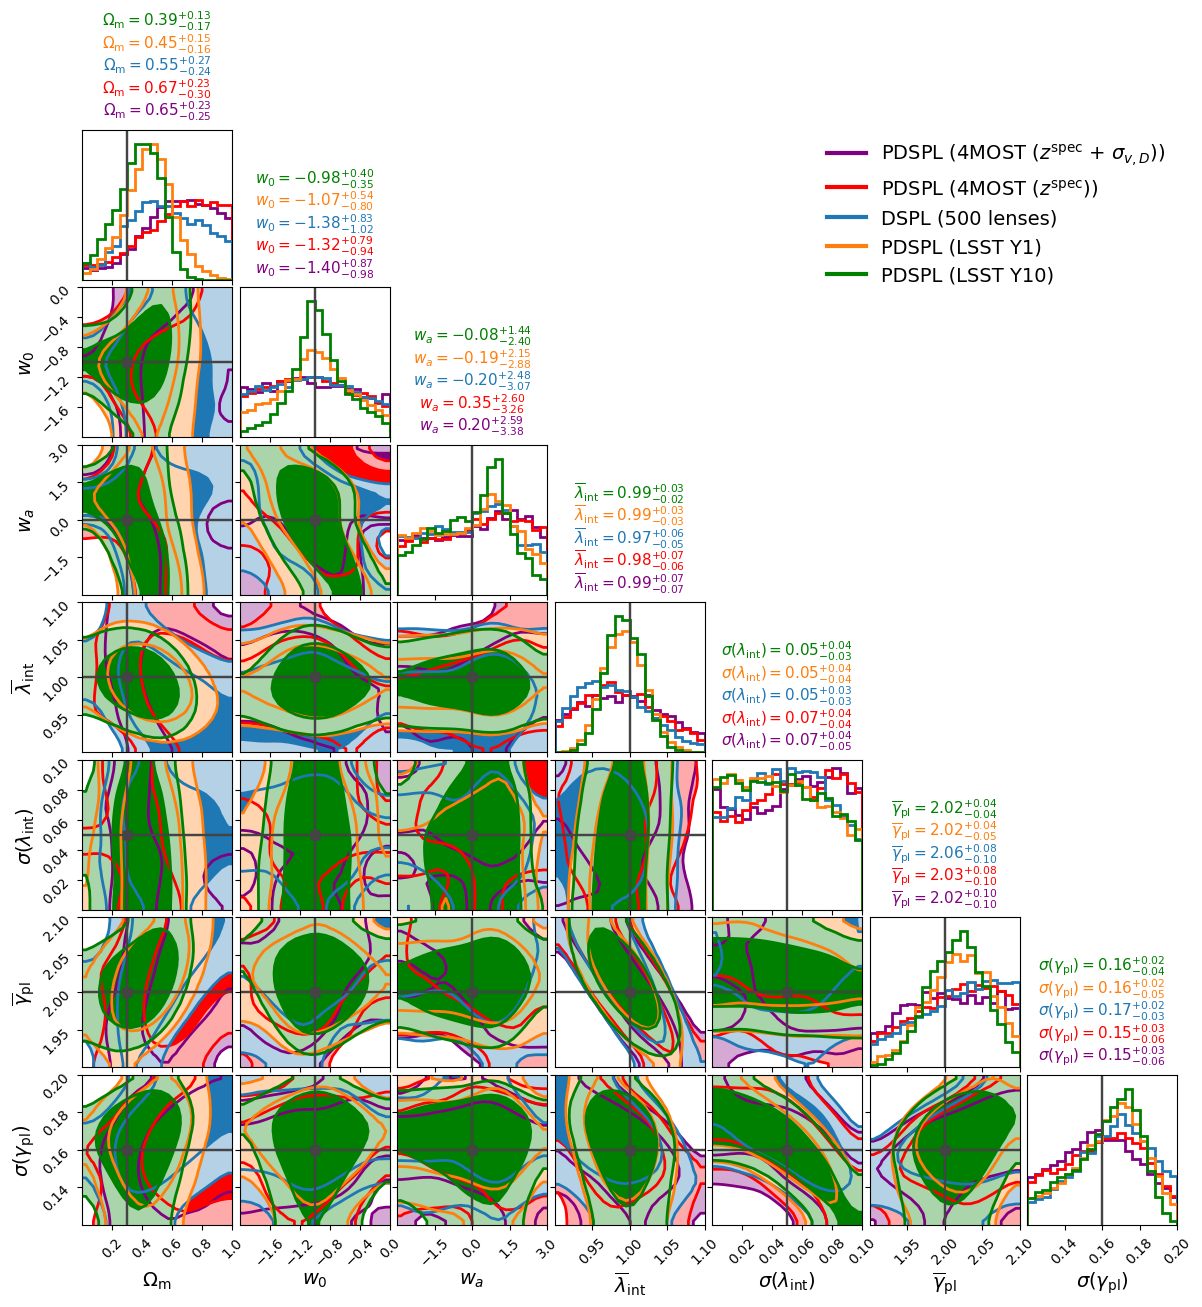

In [ ]:

scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v',
    'lsst_4most_spec-z', 
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  b. DSPL, LSST Y1, and LSST Y10 Scatter Plot -- Uniform Priors

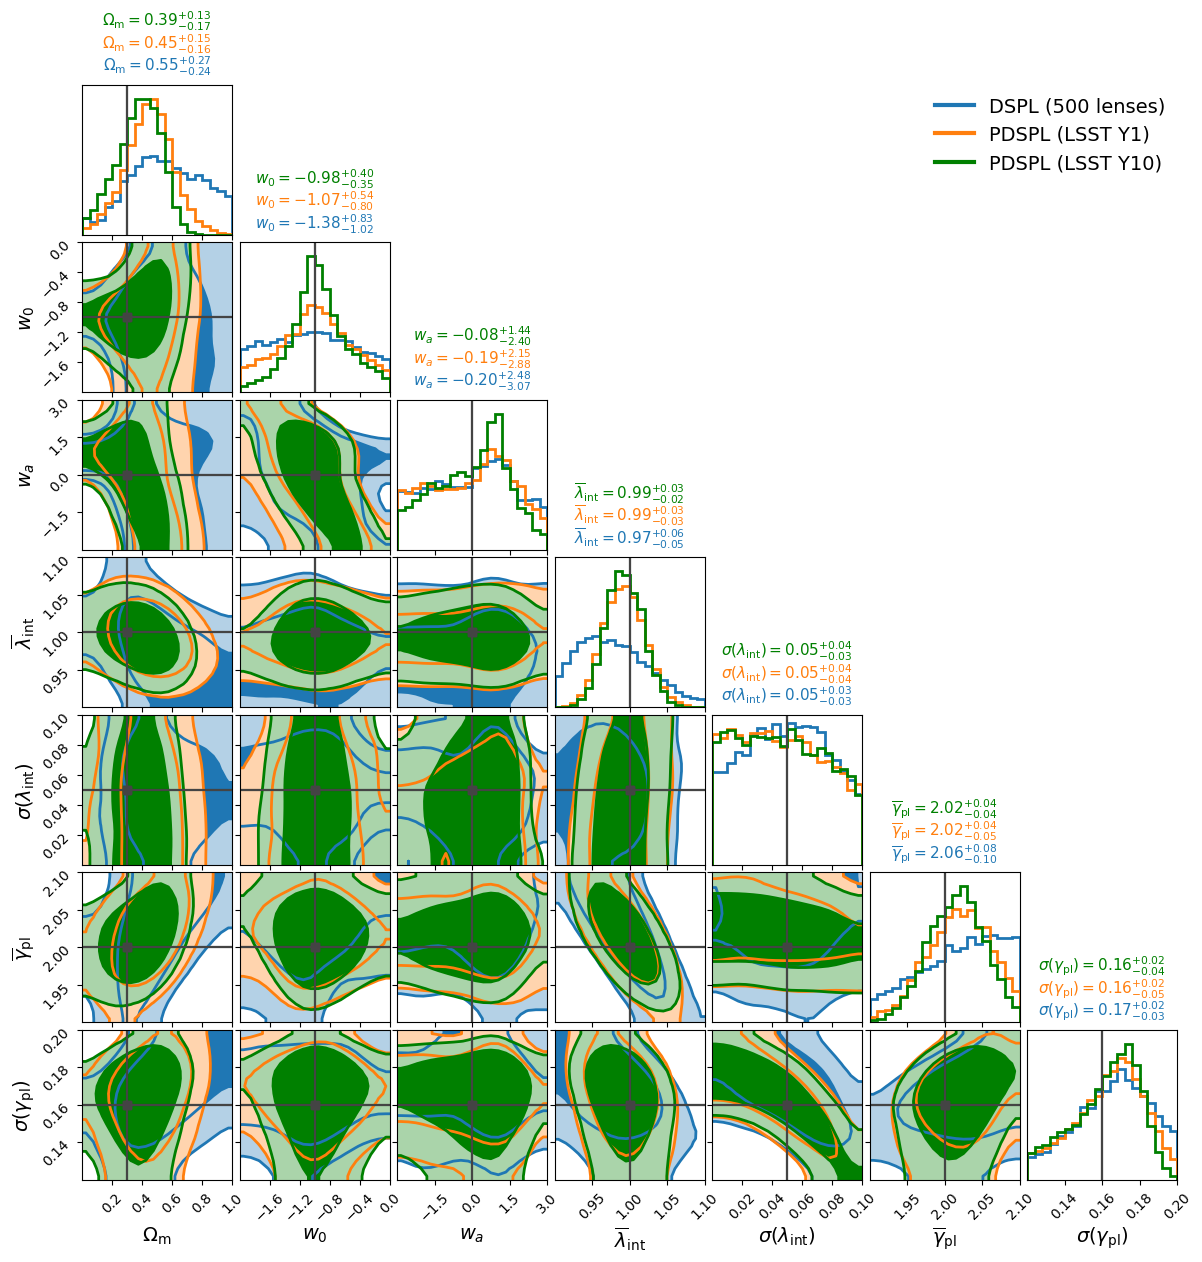

In [ ]:
# Assuming 'scenarios', 'truth', and 'fixed_params' are already defined above

scenarios_to_plot = [
    'DSPL', 
    'lsst_y1', 
    'lsst_y10'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  c. All Scenarios Corner Plot -- $\Omega_m$ Prior

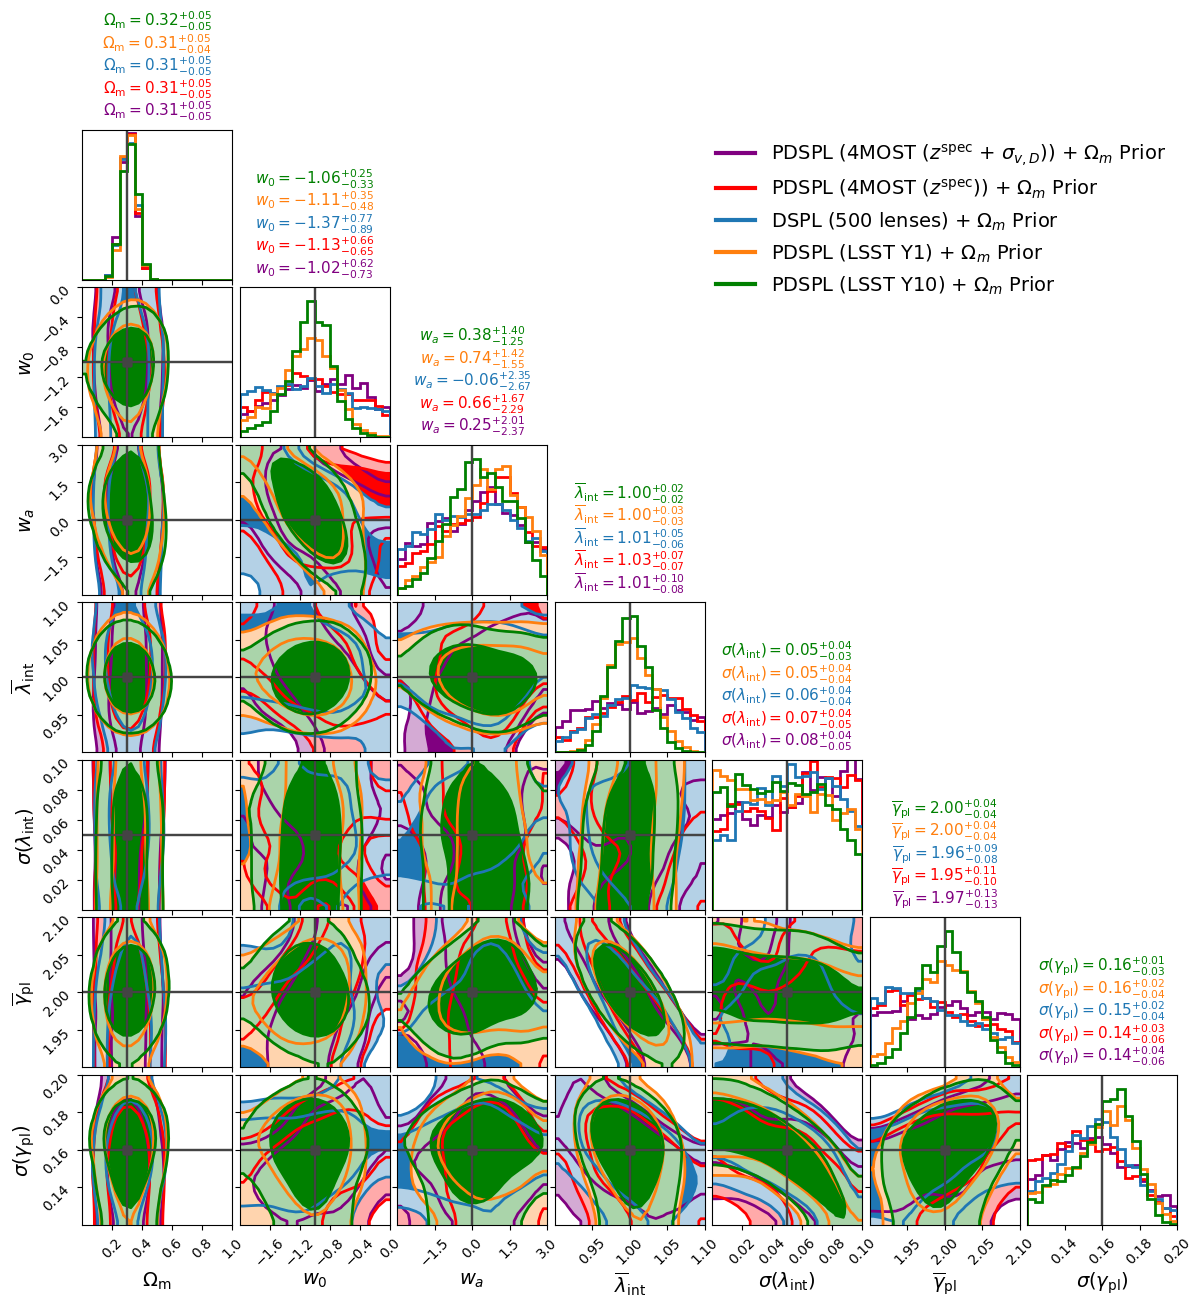

In [ ]:
# Assuming 'scenarios', 'truth', and 'fixed_params' are already defined above

scenarios_to_plot = [
    'lsst_4most_spec-z_sigma_v_om_prior',
    'lsst_4most_spec-z_om_prior', 
    'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  b. DSPL, LSST Y1, and LSST Y10 Corner Plot -- $\Omega_m$ Prior

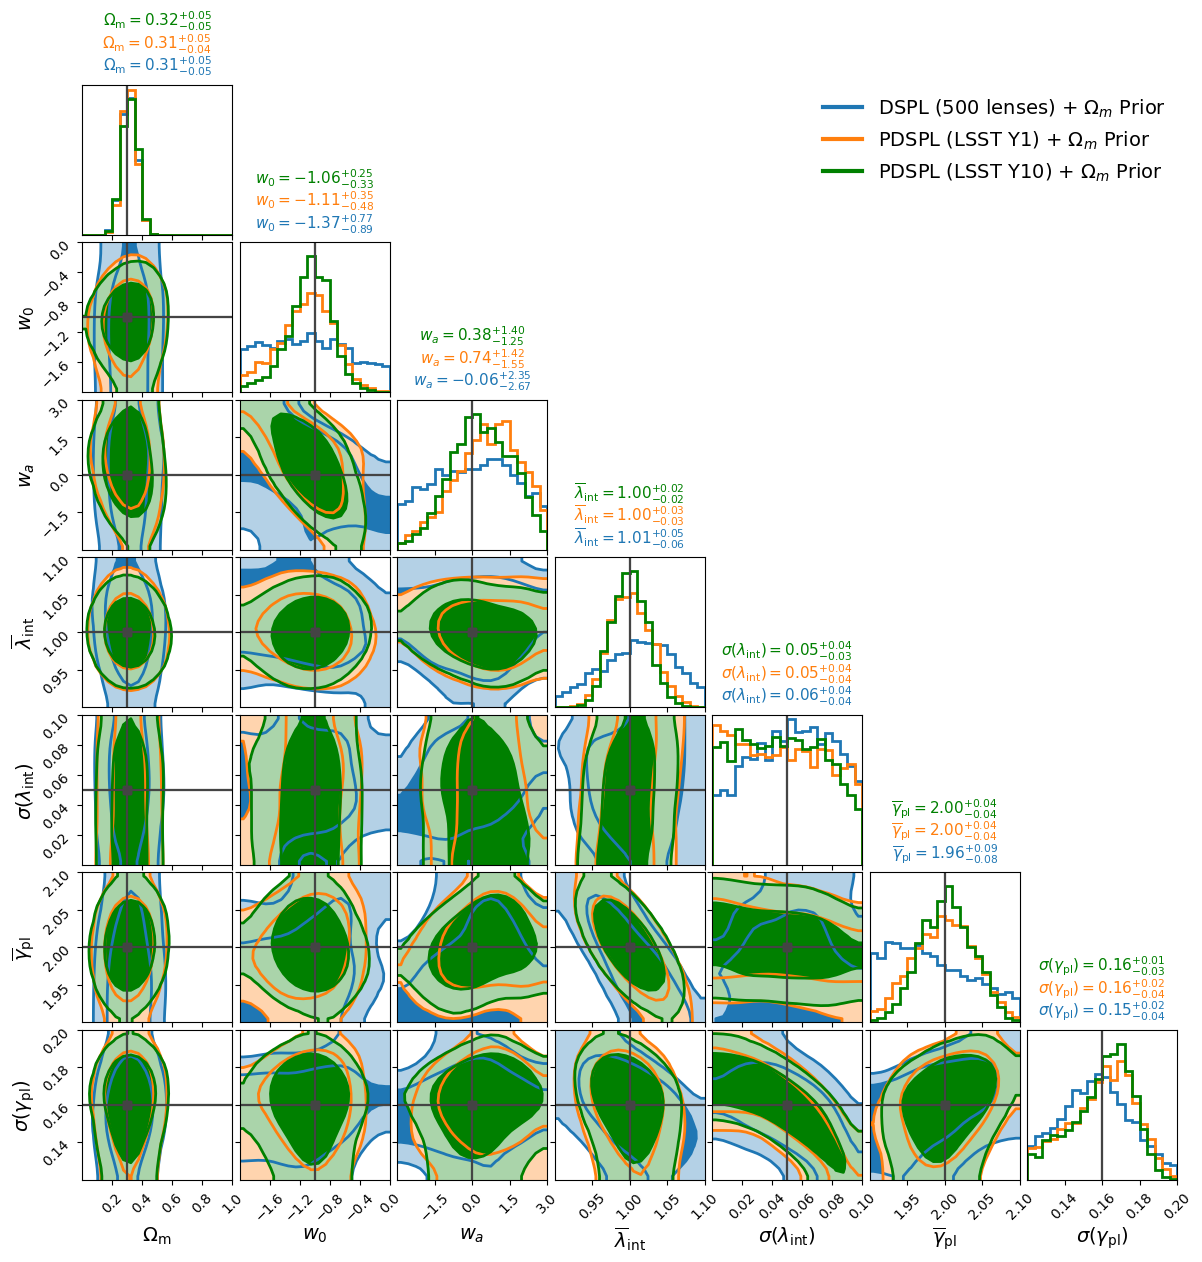

In [ ]:
scenarios_to_plot = [
    'DSPL_om_prior', 
    'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

###  c. LSST Y10 Corner Plot -- With and Without $\Omega_m$ Prior

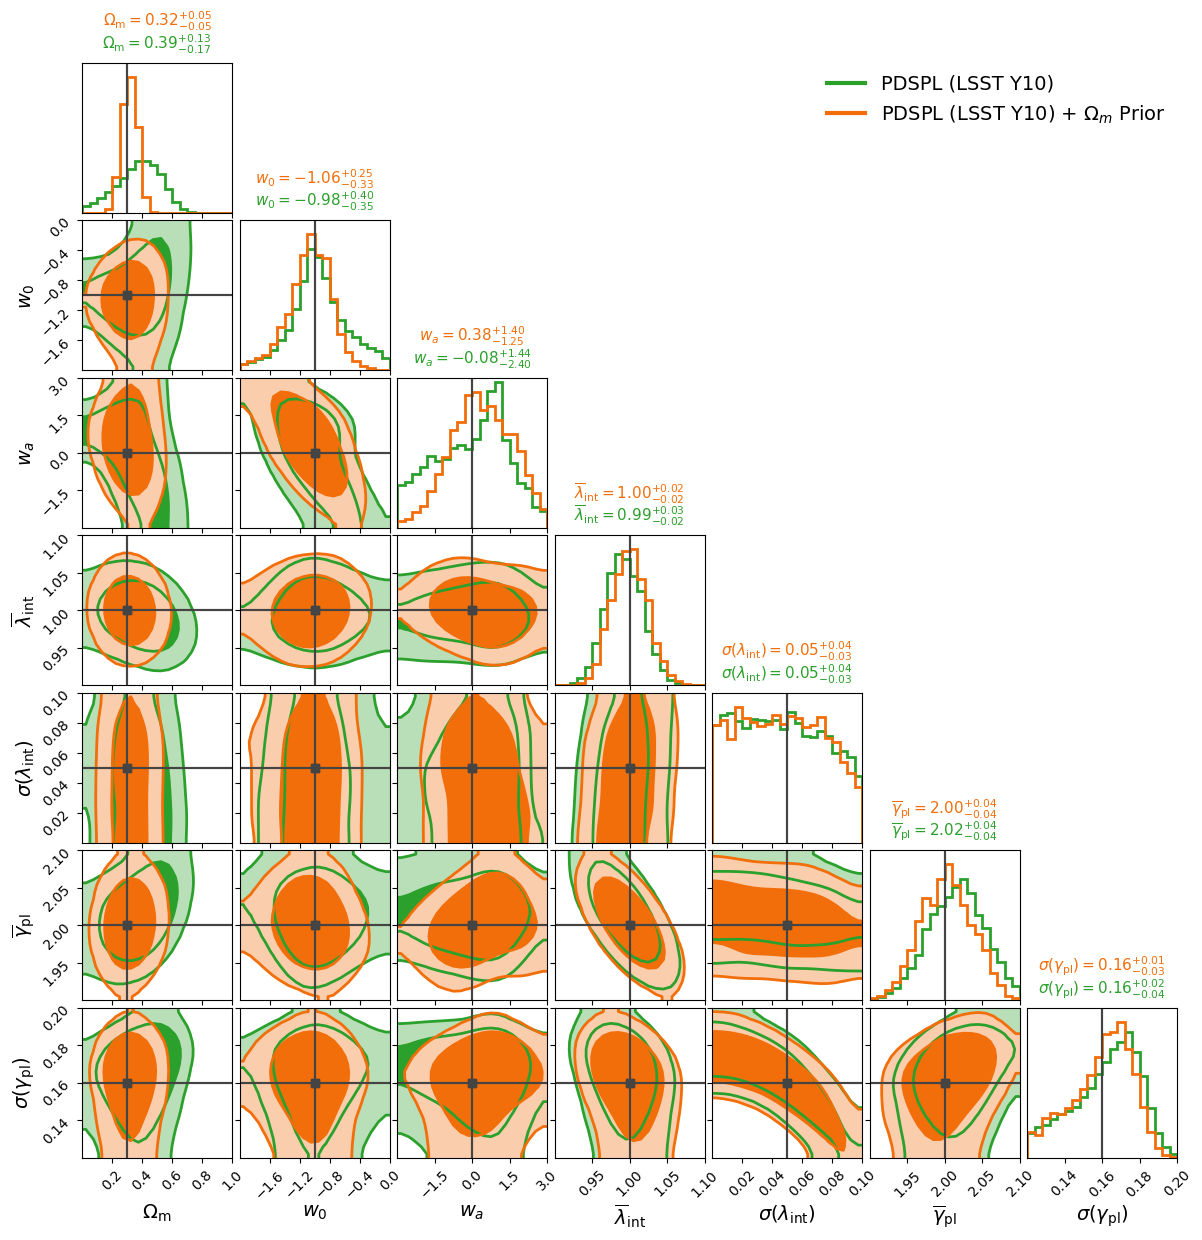

In [ ]:
# Assuming 'scenarios', 'truth', and 'fixed_params' are already defined above

scenarios_to_plot = [
    # 'DSPL',
    # 'lsst_y1',
    'lsst_y10',
    # 'DSPL_om_prior', 
    # 'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

custom_colors_dict = {
    # 'DSPL': '#1f77b4',
    # 'lsst_y1': '#ff7f0e',
    'lsst_y10': '#2ca02c',
    # 'DSPL_om_prior': '#1f77b4',
    # 'lsst_y1_om_prior': '#ff7f0e',
    'lsst_y10_om_prior': "#f26e0a"
}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

plt.show()

###  d. LSST Y10 vs DSPL Corner Plot -- With and Without $\Omega_m$ Prior

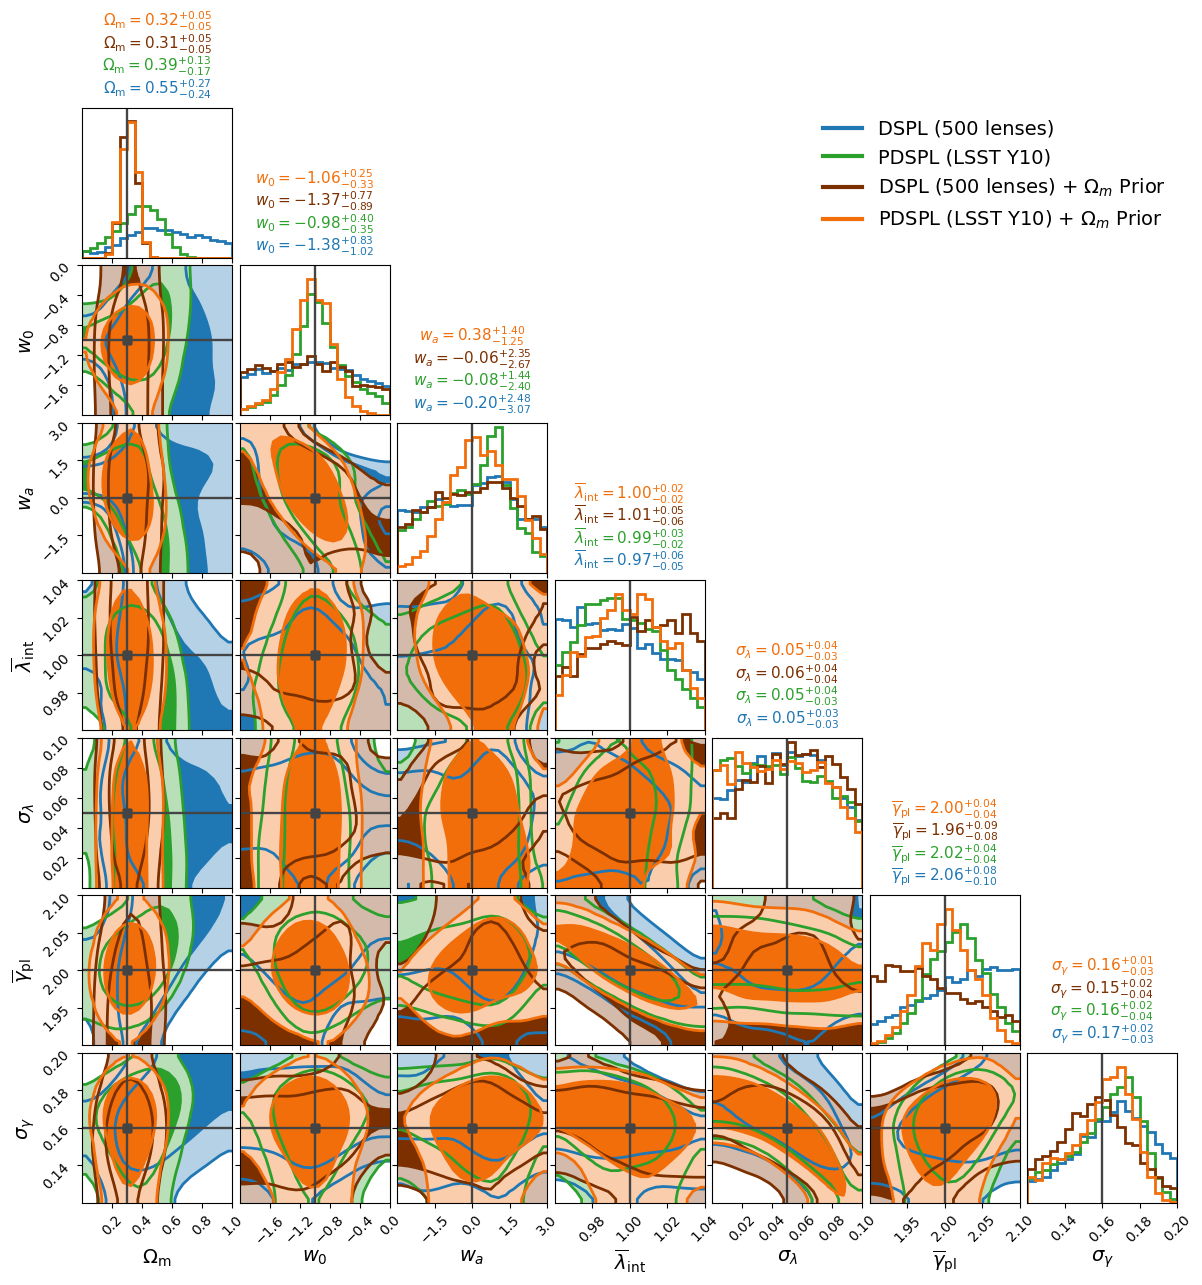

In [ ]:
# Assuming 'scenarios', 'truth', and 'fixed_params' are already defined above

latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma_{\gamma}$", 
    'lambda_sigma': r"$\sigma_{\lambda}$"
}

custom_ranges = [
    (0, 1),           # om
    (-2, 0),          # w0
    (-3, 3),          # wa
    (0.96, 1.04),     # lambda_int
    (0.0, 0.10),      # lambda_sigma
    (1.9, 2.1),       # gamma_pl
    (0.12, 0.20),     # gamma_sigma
]

scenarios_to_plot = [
    'DSPL',
    # 'lsst_y1',
    'lsst_y10',
    'DSPL_om_prior', 
    # 'lsst_y1_om_prior', 
    'lsst_y10_om_prior'
]

custom_colors_dict = {
    'DSPL': '#1f77b4',
    # 'lsst_y1': '#ff7f0e',
    'lsst_y10': '#2ca02c',
    'DSPL_om_prior': "#7c3000",
    # 'lsst_y1_om_prior': '#ff7f0e',
    'lsst_y10_om_prior': "#f26e0a"
}

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True,
    custom_colors_dict=custom_colors_dict
)

plt.show()

## Table of All Forecast Results

In [ ]:
# print a latex table of the median and 16th/84th percentiles for each parameter and scenario
print("\n--- Parameter Summary Table (Median with 16th/84th Percentiles) ---")
print(f"{'Scenario':<80} | {'Parameter':<30} | {'Median':<10} | {'-1σ':<10} | {'+1σ':<10}")
print("-" * 150) 
for key in scenarios.keys():
    sc = scenarios[key]
    if 'samples' not in sc:
        continue
    
    samples = sc['samples']
    scenario_name = sc['name']
    
    for param_idx, param_key in enumerate(param_labels):
        samples_1d = samples[:, param_idx]
        q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
        lower_err = q50 - q16
        upper_err = q84 - q50
        
        print(f"{scenario_name:<80} | {param_key:<30} | {q50:<10.3f} | {lower_err:<10.3f} | {upper_err:<10.3f}")


--- Parameter Summary Table (Median with 16th/84th Percentiles) ---
Scenario                                                                         | Parameter                      | Median     | -1σ        | +1σ       
------------------------------------------------------------------------------------------------------------------------------------------------------
PDSPL (LSST Y1)                                                                  | $\Omega_m$                     | 0.450      | 0.161      | 0.146     
PDSPL (LSST Y1)                                                                  | $w_0$                          | -1.075     | 0.803      | 0.536     
PDSPL (LSST Y1)                                                                  | $w_a$                          | -0.188     | 2.877      | 2.148     
PDSPL (LSST Y1)                                                                  | $\bar{\lambda}_{int}$          | 0.992      | 0.027      | 0.028     
PDSPL (LSST Y1)

In [ ]:
# save the scenarios dictionary with the samples included into a new pickle file for later use
with open('../data/samples/forecast_scenarios_w0waCDM_fixed_scatter_custom.pkl', 'wb') as f:
    pickle.dump(scenarios, f)

## Experiment 1 - Effect of Photometric Redshift Uncertainties on Forecasts